# Neural Network Term Classification (PyTorch)

This notebook trains **PyTorch neural network models** for multi-label term prediction.

**Why Neural Networks?**
- Can learn complex non-linear patterns
- Flexible architecture design
- Good for high-dimensional embeddings
- Native support for multi-label classification

**Architectures:**
1. Simple feedforward (baseline)
2. Deep with batch normalization
3. Regularized with L2 penalties

**Dataset:** CogAtlas terms with threshold 0.5789

**Key Metrics:** Recall@5, Recall@10

## Setup

In [9]:
import os

import sys
sys.path.append(os.path.abspath('../../'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import json

from neurovlm.term_classification_models import (
    load_and_align_term_data,
    evaluate_term_prediction,
    print_term_evaluation_results,
    train_neural_classifier,
    plot_training_history,
)

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

torch.set_default_device("cpu")

# Set random seeds
np.random.seed(42)
torch.manual_seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.10.0
CUDA available: False


## 1. Load Data

In [16]:
# Load CogAtlas term data with threshold 0.6500
print("Loading CogAtlas term data (threshold 0.6500)...")
X, y, pmids, term_names = load_and_align_term_data(
    data_source="cogatlas_threshold", threshold=0.65
)

print(f"\nDataset shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Number of terms: {len(term_names)}")

Loading CogAtlas term data (threshold 0.6500)...
Loading brain vectors...
Applying InfoNCE projection head...
Using projected features (dim: 384)...
Loading term labels...
Aligning data...
Brain vectors: 29868
Labeled papers: 22155
Common PMIDs: 21549

Aligned dataset:
  Brain vectors: (21549, 384)
  Term labels: (21549, 814)
  Number of terms: 814

Label statistics:
  Terms per paper: mean=28.7, std=33.2
  Papers per term: mean=758.5, std=600.4

Dataset shape: (21549, 384)
Labels shape: (21549, 814)
Number of terms: 814


In [17]:
# Load category info if available
try:
    with open('cogatlas_term_threshold_0_6500_category_info.json', 'r') as f:
        category_info = json.load(f)
    print("Category info loaded successfully")
    print(f"Number of terms with category info: {len(category_info)}")
except FileNotFoundError:
    category_info = None
    print("No category info file found")

Category info loaded successfully
Number of terms with category info: 4


## 2. Train/Test Split and Preprocessing

In [18]:
# Split data
X_train, X_test, y_train, y_test, pmids_train, pmids_test = train_test_split(
    X, y, pmids, test_size=0.2, random_state=42
)

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# Store dimensions
input_dim = X_train.shape[1]
output_dim = y_train.shape[1]

print(f"\nInput dimension: {input_dim}")
print(f"Output dimension: {output_dim}")

Train set: (17239, 384)
Test set: (4310, 384)

Input dimension: 384
Output dimension: 814


In [19]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features standardized")
print(f"Train mean: {X_train_scaled.mean():.6f}, std: {X_train_scaled.std():.6f}")
print(f"Test mean: {X_test_scaled.mean():.6f}, std: {X_test_scaled.std():.6f}")

Features standardized
Train mean: -0.000000, std: 1.000000
Test mean: 0.000374, std: 0.999974


In [20]:
from sklearn.decomposition import PCA
# Apply PCA
print("Applying PCA...")
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"Explained variance: {pca.explained_variance_ratio_.sum():.2%}")
print(f"Shape after PCA: {X_train_pca.shape}")


# Standardize features
scaler = StandardScaler()
X_train_scaled_pca = scaler.fit_transform(X_train_pca)
X_test_scaled_pca = scaler.transform(X_test_pca)

print("Features standardized")
print(f"Train mean: {X_train_scaled_pca.mean():.6f}, std: {X_train_scaled_pca.std():.6f}")
print(f"Test mean: {X_test_scaled_pca.mean():.6f}, std: {X_test_scaled_pca.std():.6f}")

Applying PCA...
Explained variance: 95.06%
Shape after PCA: (17239, 118)
Features standardized
Train mean: 0.000000, std: 1.000000
Test mean: -0.000372, std: 1.001280


## 3. Neural Network Models (Random Initialization)

**Clean training without warm-start:**
- Random initialization allows full freedom to learn optimal representations
- No constraint to preserve a linear solution
- Better LRAP (ranking quality) than warm-start approach

MODEL 1: [1024, 512] hidden layers
Input dimension: 384
Output dimension: 814
Training samples: 20196
Test samples: 5050

BUILDING MODEL
Architecture: 384 -> 1024 -> 512 -> 814
Activation: gelu
Batch normalization: True
Dropout: 0.3
Total parameters: 1,339,694

TRAINING
Training set: 17166 samples
Validation set: 3030 samples
Pos-weight scale: 0.5, range: 2.12 to 21.81
Using device: cpu
Epoch 1/200 - Loss: 0.7400 - F1: 0.1608 - Val Loss: 0.5715 - Val F1: 0.2831 - LR: 1.00e-03
Epoch 6/200 - Loss: 0.3964 - F1: 0.3291 - Val Loss: 0.4231 - Val F1: 0.3099 - LR: 8.54e-04
Epoch 11/200 - Loss: 0.3610 - F1: 0.3836 - Val Loss: 0.4342 - Val F1: 0.2958 - LR: 5.01e-04
Epoch 16/200 - Loss: 0.3327 - F1: 0.4297 - Val Loss: 0.4456 - Val F1: 0.2835 - LR: 1.47e-04
Epoch 21/200 - Loss: 0.3214 - F1: 0.4498 - Val Loss: 0.4481 - Val F1: 0.2871 - LR: 1.00e-03

Early stopping triggered at epoch 25
Best validation loss: 0.4205

Optimal threshold: 0.430

EVALUATION ON TEST SET
Threshold:                   0.430


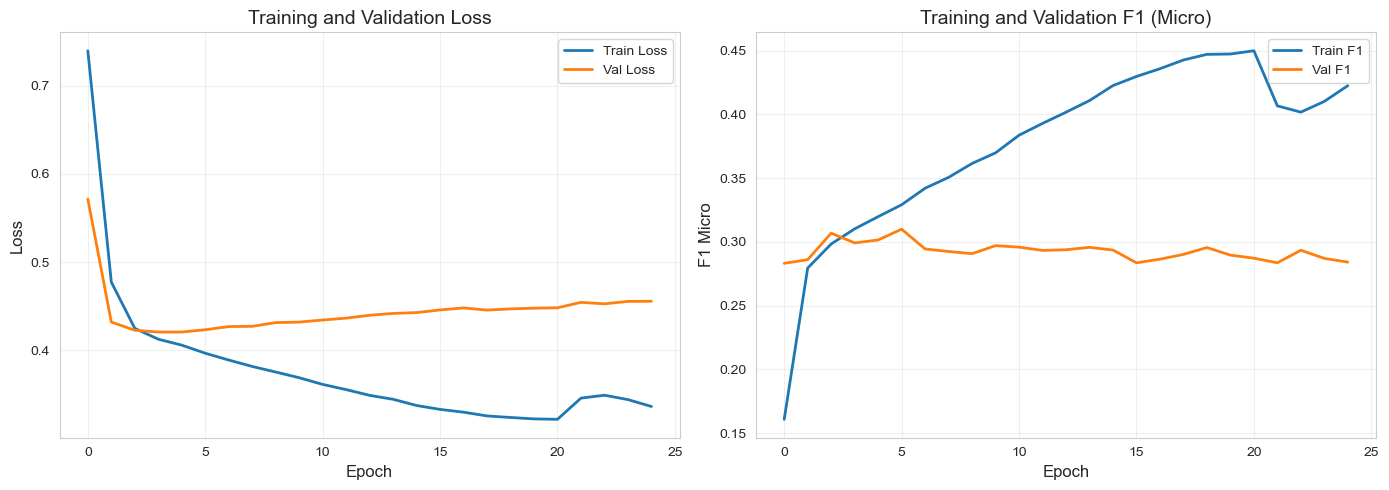

In [15]:
print("="*70)
print("MODEL 1: [1024, 512] hidden layers")
print("="*70)

model_1, history_1, metrics_1 = train_neural_classifier(
    X_train_scaled, y_train, X_test_scaled, y_test,
    hidden_dims=[1024, 512],
    activation='gelu',
    dropout=0.3,
    use_batchnorm=True,
    learning_rate=1e-3,
    weight_decay=1e-2,
    pos_weight_scale=0.5,
    loss_type='bce',
    epochs=200,
    batch_size=256,
    patience=20,
    scheduler_type='cosine',
    grad_clip=1.0,
    verbose=1
)

plot_training_history(history_1)